In [2]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Normalization, Lambda, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Config
# -----------------------------
X_PATH_ROUTER = "../../../data/training/RouterV2.0_training_X.npy"  # (N,4,4) – includes classes 0,1,2,3
Y_PATH_ROUTER = "../../../data/training/RouterV2.0_training_y.npy"  # (N,)   – labels in {0,1,2,3}

SAVE_PATH = "../../../models/Model1/model1_cnn.keras"

EPOCHS      = 120
BATCH_SIZE  = 128
VAL_SPLIT   = 0.15
LR          = 5e-4
NUM_CLASSES = 3   # M1 now predicts only 0=Off, 1=Start, 2=Load
SEED = 42
rng = np.random.default_rng(SEED)

# -----------------------------
# Load
# -----------------------------
X = np.load(X_PATH_ROUTER).astype(np.float32)  # (N,4,4)
y = np.load(Y_PATH_ROUTER).astype(np.int64)    # (N,)

assert X.ndim == 3 and X.shape[1:] == (4, 4), f"X must be (N,4,4), got {X.shape}"
uniq_raw = set(np.unique(y).tolist())
assert uniq_raw.issubset({0,1,2,3}), f"labels must be in {0,1,2,3}, got {uniq_raw}"

# -----------------------------
# Filter out UNKNOWN (label 3)
# -----------------------------
mask = (y != 3)
X = X[mask]
y = y[mask]

uniq = set(np.unique(y).tolist())
assert uniq.issubset({0,1,2}) and len(uniq) > 0, f"after filtering, labels must be subset of {0,1,2}, got {uniq}"

# Shuffle AFTER filtering
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

# -----------------------------
# Normalization (fit on filtered values only)
# -----------------------------
norm = Normalization(axis=-1)
norm.adapt(X)

# -----------------------------
# Class weights (data-driven on filtered set)
# -----------------------------
counts = np.bincount(y, minlength=NUM_CLASSES).astype(np.float32)
w = counts.sum() / (counts + 1e-6)
w = (w / w.mean()).tolist()
class_weight = {i: float(wi) for i, wi in enumerate(w)}

# Optional tweak: slightly boost Engine Load (class 2)
class_weight[2] = class_weight.get(2, 1.0) * 1.25
print("Adjusted class weights:", class_weight)

# -----------------------------
# Model: values + per-step deltas
# -----------------------------
x_in = Input(shape=(4, 4), name="win")
x_norm = norm(x_in)

def deltas_fn(t):
    d = t[:, 1:, :] - t[:, :-1, :]        # (B,3,4)
    zero = tf.zeros_like(d[:, :1, :])     # (B,1,4)
    return tf.concat([zero, d], axis=1)   # (B,4,4)

deltas = Lambda(deltas_fn, name="deltas", output_shape=(4, 4))(x_in)
x_cat  = Concatenate(axis=-1, name="values_plus_deltas")([x_norm, deltas])  # (B,4,8)

h = Conv1D(64, kernel_size=2, activation='relu', padding='valid')(x_cat)   # -> (B,3,64)
h = Conv1D(128, kernel_size=2, activation='relu', padding='valid')(h)      # -> (B,2,128)
h = Flatten()(h)                                                            # -> (B,256)
h = Dropout(0.3)(h)
h = Dense(128, activation='relu')(h)
h = Dropout(0.2)(h)
out = Dense(NUM_CLASSES, activation='softmax')(h)

model = Model(x_in, out, name="router_cnn_with_deltas_no_unknown")
model.compile(optimizer=Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6),
    ],
    verbose=1
)

# -----------------------------
# Save
# -----------------------------
Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
model.save(SAVE_PATH)
print(f"✅ Model saved: {SAVE_PATH}")


Adjusted class weights: {0: 1.591870665550232, 1: 1.1968368291854858, 2: 0.26411576196551323}
Epoch 1/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8039 - loss: 3.5891 - val_accuracy: 0.8770 - val_loss: 0.5468 - learning_rate: 5.0000e-04
Epoch 2/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8677 - loss: 0.3061 - val_accuracy: 0.9274 - val_loss: 0.3231 - learning_rate: 5.0000e-04
Epoch 3/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9037 - loss: 0.1718 - val_accuracy: 0.9280 - val_loss: 0.2663 - learning_rate: 5.0000e-04
Epoch 4/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9221 - loss: 0.1425 - val_accuracy: 0.9242 - val_loss: 0.2775 - learning_rate: 5.0000e-04
Epoch 5/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9161 - loss: 0.1459 - val_accuracy: 0.9400 - val_loss: 0.2387 - learning_rate: 5.0000e-04
Epoch 6/120
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9200 - loss: 0.1317 - val_accuracy: 0.9345 - val_loss:

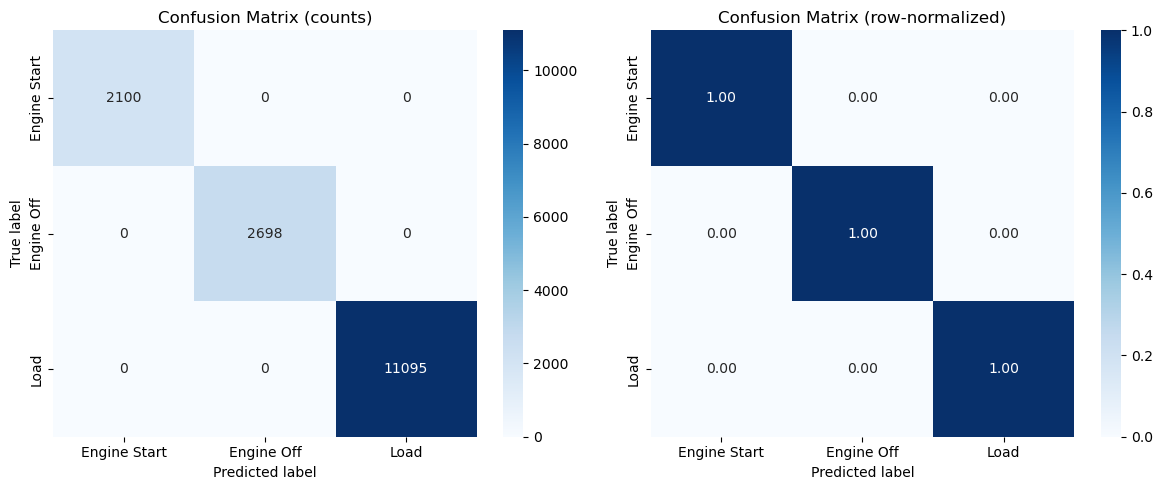

Accuracy: 1.0000
              precision    recall  f1-score   support

Engine Start      1.000     1.000     1.000      2100
  Engine Off      1.000     1.000     1.000      2698
        Load      1.000     1.000     1.000     11095

    accuracy                          1.000     15893
   macro avg      1.000     1.000     1.000     15893
weighted avg      1.000     1.000     1.000     15893



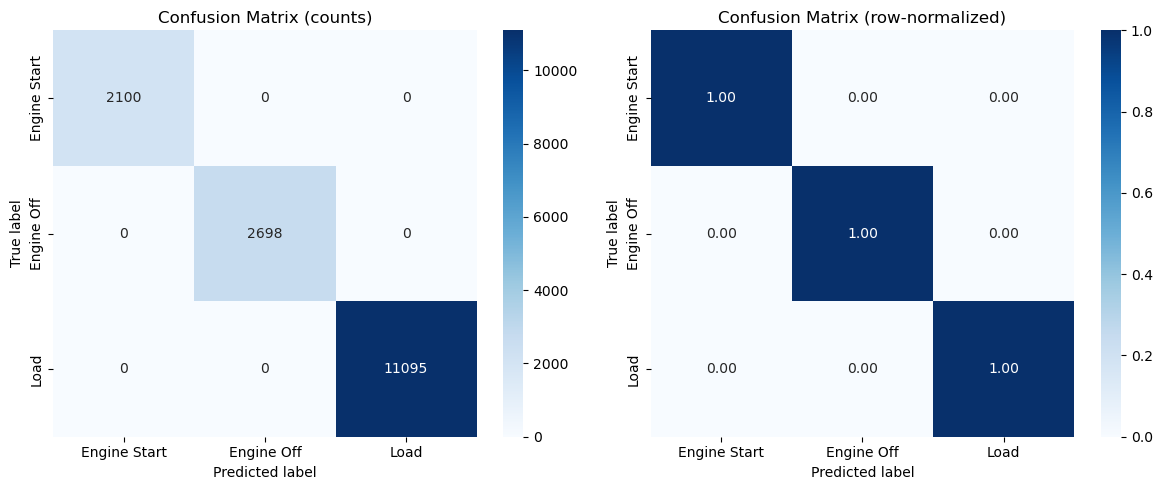

Accuracy: 1.0000
              precision    recall  f1-score   support

Engine Start      1.000     1.000     1.000      2100
  Engine Off      1.000     1.000     1.000      2698
        Load      1.000     1.000     1.000     11095

    accuracy                          1.000     15893
   macro avg      1.000     1.000     1.000     15893
weighted avg      1.000     1.000     1.000     15893



In [3]:
# ==== EVAL: Confusion matrix & report for Model 1 (Router, 3-class) ====
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Optional seaborn; fallback to matplotlib if unavailable
try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

# =========================
# Config
# =========================
TEST_SOURCE = "v2"  # set to "legacy" if you want to use the old split

# Paths (legacy)
X_PATH_ROUTER_TEST     = "../../../data/test/Router_test_X.npy"
Y_PATH_ROUTER_TEST     = "../../../data/test/Router_test_y.npy"
X_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_X.npy"
Y_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_y.npy"

# Paths (V2.0)
X_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_X.npy"
Y_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_y.npy"

# Fixed label space and display names (Unknown removed)
LABELS = [0, 1, 2]
NAMES  = ["Engine Start", "Engine Off", "Load"]

# =========================
# Load test data
# =========================
def _np_load(path, astype=None):
    if not os.path.exists(path):
        return None
    arr = np.load(path, allow_pickle=True)
    if astype is not None:
        arr = arr.astype(astype)
    return arr

def load_test_split(test_source="v2"):
    if test_source == "v2":
        X = _np_load(X_PATH_ROUTER_V2_TEST, np.float32)
        y = _np_load(Y_PATH_ROUTER_V2_TEST, np.int64)
        if X is None or y is None:
            raise FileNotFoundError("RouterV2.0 test split not found.")
        # Filter out Unknowns (label=3)
        mask = (y != 3)
        X, y = X[mask], y[mask]
        return X, y
    elif test_source == "legacy":
        X1 = _np_load(X_PATH_ROUTER_TEST, np.float32)
        y1 = _np_load(Y_PATH_ROUTER_TEST, np.int64)
        if X1 is None or y1 is None:
            raise FileNotFoundError("Legacy Router_test split not found.")
        # OCC is optional; include if present
        X2 = _np_load(X_PATH_ROUTER_OCC_TEST, np.float32)
        y2 = _np_load(Y_PATH_ROUTER_OCC_TEST, np.int64)
        if X2 is not None and y2 is not None:
            X = np.concatenate([X1, X2], axis=0)
            y = np.concatenate([y1, y2], axis=0)
        else:
            X, y = X1, y1
        # Filter out Unknowns (label=3)
        mask = (y != 3)
        X, y = X[mask], y[mask]
        return X, y
    else:
        raise ValueError("Invalid TEST_SOURCE. Use 'v2' or 'legacy'.")

X_test, y_true = load_test_split(TEST_SOURCE)

# Sanity checks
if X_test.ndim != 3 or X_test.shape[1:] != (4, 4):
    raise ValueError(f"X_test shape must be (N,4,4); got {X_test.shape}")
if y_true.ndim != 1:
    y_true = y_true.reshape(-1)
if not np.all(np.isin(y_true, LABELS)):
    bad = np.unique(y_true[~np.isin(y_true, LABELS)])
    raise ValueError(f"y_true contains labels outside {LABELS}: {bad}")

# =========================
# Predict
# =========================
y_prob = model.predict(X_test, verbose=0)
if y_prob.ndim != 2 or y_prob.shape[1] != len(LABELS):
    raise ValueError(f"model.predict output must be (N, {len(LABELS)}); got {y_prob.shape}")
y_pred = y_prob.argmax(axis=1)

# =========================
# Confusion matrices
# =========================
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

row_sums = cm.sum(axis=1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = np.divide(cm.astype(np.float32), row_sums, where=(row_sums != 0))
    cm_norm = np.nan_to_num(cm_norm, nan=0.0, posinf=0.0, neginf=0.0)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

def _plot_mat(mat, ax_, title, fmt, is_norm=False):
    if _HAS_SNS:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=NAMES, yticklabels=NAMES, ax=ax_,
                    vmin=0.0 if is_norm else None, vmax=1.0 if is_norm else None)
    else:
        im = ax_.imshow(mat, aspect="auto", interpolation="nearest")
        ax_.set_xticks(range(len(NAMES))); ax_.set_yticks(range(len(NAMES)))
        ax_.set_xticklabels(NAMES, rotation=45, ha="right")
        ax_.set_yticklabels(NAMES)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax_.text(j, i, (f"{mat[i,j]:.2f}" if is_norm else f"{int(mat[i,j])}"),
                         ha="center", va="center")
        fig.colorbar(im, ax=ax_)
    ax_.set_title(title)
    ax_.set_xlabel("Predicted label"); ax_.set_ylabel("True label")

_plot_mat(cm,      ax[0], "Confusion Matrix (counts)",       "d",   is_norm=False)
_plot_mat(cm_norm, ax[1], "Confusion Matrix (row-normalized)",".2f", is_norm=True)

plt.tight_layout()
plt.show()

# =========================
# Metrics
# =========================
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, labels=LABELS, target_names=NAMES, digits=3))


# ==== EVAL: Confusion matrix & report for Model 1 (Router, 3-class: 0=Start,1=Off,2=Load) ====
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Optional seaborn; fallback to matplotlib if unavailable
try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

# =========================
# Config
# =========================
# Choose test source: "legacy" -> Router_test (+ optional RouterOCC_test),
#                     "v2"     -> RouterV2.0_test
TEST_SOURCE = "v2"  # set to "legacy" if you want to use the old split

# Paths (legacy)
X_PATH_ROUTER_TEST     = "../../../data/test/Router_test_X.npy"
Y_PATH_ROUTER_TEST     = "../../../data/test/Router_test_y.npy"
X_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_X.npy"
Y_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_y.npy"  # usually all 3s

# Paths (V2.0)
X_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_X.npy"
Y_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_y.npy"

# Fixed label space and display names (M1 no longer predicts Unknown/3)
LABELS = [0, 1, 2]
NAMES  = ["Engine Start", "Engine Off", "Load"]

# =========================
# Load test data
# =========================
def _np_load(path, astype=None):
    if not os.path.exists(path):
        return None
    arr = np.load(path, allow_pickle=True)
    if astype is not None:
        arr = arr.astype(astype)
    return arr

def load_test_split(test_source="v2"):
    if test_source == "v2":
        X = _np_load(X_PATH_ROUTER_V2_TEST, np.float32)
        y = _np_load(Y_PATH_ROUTER_V2_TEST, np.int64)
        if X is None or y is None:
            raise FileNotFoundError("RouterV2.0 test split not found.")
        return X, y
    elif test_source == "legacy":
        X1 = _np_load(X_PATH_ROUTER_TEST, np.float32)
        y1 = _np_load(Y_PATH_ROUTER_TEST, np.int64)
        if X1 is None or y1 is None:
            raise FileNotFoundError("Legacy Router_test split not found.")
        # OCC is optional; include if present
        X2 = _np_load(X_PATH_ROUTER_OCC_TEST, np.float32)
        y2 = _np_load(Y_PATH_ROUTER_OCC_TEST, np.int64)
        if X2 is not None and y2 is not None:
            X = np.concatenate([X1, X2], axis=0)
            y = np.concatenate([y1, y2], axis=0)
        else:
            X, y = X1, y1
        return X, y
    else:
        raise ValueError("Invalid TEST_SOURCE. Use 'v2' or 'legacy'.")

X_test, y_true = load_test_split(TEST_SOURCE)

# Sanity checks
if X_test.ndim != 3 or X_test.shape[1:] != (4, 4):
    raise ValueError(f"X_test shape must be (N,4,4); got {X_test.shape}")
if y_true.ndim != 1:
    y_true = y_true.reshape(-1)

# =========================
# Filter out Unknown (label 3) — evaluated by M0 elsewhere
# =========================
mask = (y_true != 3)
X_test = X_test[mask]
y_true = y_true[mask]

if not np.all(np.isin(y_true, LABELS)):
    bad = np.unique(y_true[~np.isin(y_true, LABELS)])
    raise ValueError(f"y_true contains labels outside {LABELS}: {bad}")

# =========================
# Load model (if not already in memory) and Predict
# =========================
try:
    model  # type: ignore[name-defined]
except NameError:
    # Reuse SAVE_PATH from training section; otherwise set explicitly here
    from tensorflow.keras.models import load_model
    model = load_model(SAVE_PATH)

y_prob = model.predict(X_test, verbose=0)
if y_prob.ndim != 2 or y_prob.shape[1] != len(LABELS):
    raise ValueError(f"model.predict output must be (N, {len(LABELS)}); got {y_prob.shape}")
y_pred = y_prob.argmax(axis=1)

# =========================
# Confusion matrices
# =========================
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

# Row-normalized confusion matrix with safe division
row_sums = cm.sum(axis=1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = np.divide(cm.astype(np.float32), row_sums, where=(row_sums != 0))
    cm_norm = np.nan_to_num(cm_norm, nan=0.0, posinf=0.0, neginf=0.0)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

def _plot_mat(mat, ax_, title, fmt, is_norm=False):
    if _HAS_SNS:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=NAMES, yticklabels=NAMES, ax=ax_,
                    vmin=0.0 if is_norm else None, vmax=1.0 if is_norm else None)
    else:
        im = ax_.imshow(mat, aspect="auto", interpolation="nearest")
        ax_.set_xticks(range(len(NAMES))); ax_.set_yticks(range(len(NAMES)))
        ax_.set_xticklabels(NAMES, rotation=45, ha="right")
        ax_.set_yticklabels(NAMES)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax_.text(j, i, (f"{mat[i,j]:.2f}" if is_norm else f"{int(mat[i,j])}"),
                         ha="center", va="center")
        fig.colorbar(im, ax=ax_)
    ax_.set_title(title)
    ax_.set_xlabel("Predicted label"); ax_.set_ylabel("True label")

_plot_mat(cm,      ax[0], "Confusion Matrix (counts)",       "d",   is_norm=False)
_plot_mat(cm_norm, ax[1], "Confusion Matrix (row-normalized)",".2f", is_norm=True)

plt.tight_layout()
plt.show()

# =========================
# Metrics
# =========================
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, labels=LABELS, target_names=NAMES, digits=3))
